(ch2-example)=

# Example 2.1: Modeling a unidirectional chemical reaction

In this example we are looking at the unidirectional binding reaction:

\begin{equation}
\mathrm{Mb} + \mathrm{O_2} \overset{k}{\longrightarrow} \mathrm{MbO_2}.
\end{equation}

As derived in the previous section, this leads to the following set of three ordinary differential equations (ODEs):

\begin{equation}
\frac{\mathrm{d[MbO_2]}}{\mathrm{d}t} = k\mathrm{[Mb][O_2]}, \qquad \frac{\mathrm{d [Mb]}}{\mathrm{d}t} = -k\mathrm{[Mb]}\mathrm{[O_2]}, \qquad \frac{\mathrm{d [O_2]}}{\mathrm{d}t} = -k\mathrm{[Mb]}\mathrm{[O_2]}.
\end{equation}

We will now solve these equations numerically. Shortly, you will repeat this exercise for the _reversible_ reaction, so this serves as a worked example that you can use as a template.

## Initial value problems

Solving these ODEs is an example of what we call an _initial value problem_. We will use the [`scipy.integrate.solve_ivp`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) function to solve this numerically. While it is not too technical to implement our own solver, our main focus is on physiological modeling, so we will rely on this robust existing solver.

If you have never solved ODEs numerically before and want to learn more about the process, we recommend the open-access book [_Finite Difference Computing with Exponential Decay Models_](http://www.springer.com/us/book/9783319294384) by Professor Hans Petter Langtangen. It provides an accessible introduction to numerical solvers and even features a sub-chapter specifically on chemical reactions.

<h3>Explanation of <code>solve_ivp</code></h3>

For the `solve_ivp` function to solve our problem, we need to supply a set of inputs:

1. The ODE system itself (the equations).
2. The _initial values_ of each state.
3. The time interval to solve over.

To specify the ODE system, we implement it as a Python function. Mathematically, we write out the derivatives of the system as a vector equation in the form:

$$\frac{\mathrm{d}\vec{y}}{\mathrm{d}t} = \vec{f}(t, \vec{y})$$

Here, $\vec{y}$ is a vector that contains all the _state variables_ of your system (the quantities you are modeling). In our example, the state vector is:

$$\vec{y} = ([\mathrm{MbO_2}], [\mathrm{Mb}], [\mathrm{O_2}])$$

The function $\vec{f}$ represents the _right-hand side_ (RHS) of the ODEs. It returns the time derivatives of each state in the system:

$$\vec{f}(t, \vec{y}) = \left( \frac{\mathrm{d[MbO_2]}}{\mathrm{d}t}, \frac{\mathrm{d[Mb]}}{\mathrm{d}t}, \frac{\mathrm{d[O_2]}}{\mathrm{d}t} \right)$$

Note that the order you list the states is not important, but it **is** important that you are consistent. The order of the states in the vector $\vec{y}$ must exactly match the order returned by your RHS function.


## Implementing the RHS function

Let us implement this RHS logic as a Python function:


In [2]:
# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [3]:
# Implement the right-hand-side of the system as a function
def rhs(t, y, k):
    # Unpack the state vector to make it easier to write neat code
    MbO2, Mb, O2 = y

    # Formulate derivatives
    dMbO2_dt = k * Mb * O2
    dMb_dt = -k * Mb * O2
    dO2_dt = -k * Mb * O2

    # Return derivatives as a vector
    return (dMbO2_dt, dMb_dt, dO2_dt)

Notice that the function _must_ take time `t` as its first argument and the state vector `y` as its second argument. This is required by `solve_ivp`. You might find this confusing since our specific ODEs do not explicitly depend on time $t$. However, a _general_ ODE might, and `solve_ivp` is designed to handle the general case. We can also add as many model parameters (like the rate constant `k`) as we want as additional arguments.


## Defining the time interval

Next, we need to define the time interval over which to solve the system. We can do this by creating a tuple of the start and finish times. For instance, if we want to solve for $t \in [0, 3]$, we write:


In [4]:
# Define the time-interval to solve for
time = (0, 3)

## Setting intitial conditions

We then define the initial conditions as a vector, typically called $\vec{y}_0$. The ordering of the states must be identical to how we defined them in the RHS function ($\text{MbO}_2$, $\text{Mb}$, $\text{O}_2$):


In [5]:
# Define the initial conditions
y0 = (0.0, 2.2, 5.4)

## Defining model parameters

Next, we define any model parameters needed to compute the problem. In this case, we only have the rate constant $k$, but let us define it in a way that can be easily scaled up for more parameters. (Some of the later models in this course will have dozens, if not hundreds, of adjustable parameters).


In [6]:
# Define model parameters
k = 1.7
params = (k,)

Here, `params` is a tuple of model parameters. Note that the trailing comma is required by Python to define a tuple when it only contains a single element.


## Running the solver

Now we are ready to call `solve_ivp`:


In [7]:
# Call the ODE solver
solution = solve_ivp(rhs, time, y0, args=params)

We send the parameters in as an optional keyword-argument called `args`. While this might look a bit technical for a single parameter, it is the best practice for larger systems. For smaller models, you could simply define the $k$ parameter inside the RHS function or as a global variable, but that approach can get messy quickly for larger models.


## Extracting and plotting results

The `solution` object returned by `solve_ivp` is a so-called "bunch" object in Python. It contains several properties we can read out. While you could try `print(solution)`, the raw output isn't very useful. Instead, let us extract the solutions and plot them.


In [8]:
# Extract the time array and the solutions of the state vectors
t = solution.t
y = solution.y

print(f"The t variable is a {t.shape} vector")
print(f"The y variable is a {y.shape} vector")

The t variable is a (20,) vector
The y variable is a (3, 20) vector


The $t$-vector contains the time points at which the solution was computed, and the $y$-vector contains the value of each state variable for each time point. Unless you love working with multi-dimensional NumPy arrays, it is often useful to split the $y$-vector back into individual state vectors:


In [9]:
# Split up into individual states
Mb, O2, MbO2 = y

print(f"Each state variable (e.g., MbO2) is now shape {MbO2.shape}")

Each state variable (e.g., MbO2) is now shape (20,)


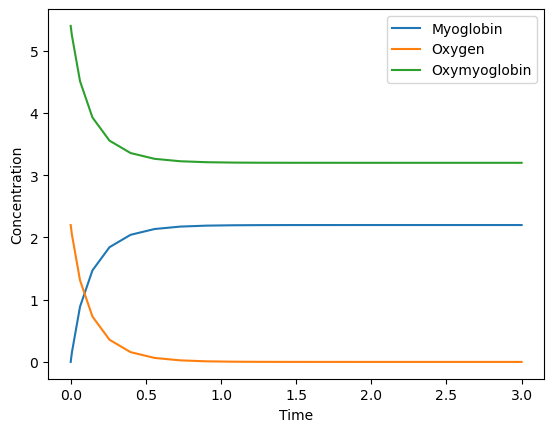

In [10]:
# Plot the results
plt.plot(t, Mb, label="Myoglobin")
plt.plot(t, O2, label="Oxygen")
plt.plot(t, MbO2, label="Oxymyoglobin")

plt.xlabel("Time")
plt.ylabel("Concentration")
plt.legend()
plt.show()

## Controlling the solver step size

Notice that we only specified the _interval_ for which we wanted to solve the equations; `solve_ivp` determined the actual time points to use. It is an _adaptive_ solver, meaning it automatically increases or decreases the time step based on how quickly the solution is changing.

However, some care must be taken here. Later in the course, you will learn about ion channels and channel _gating_. Because of gating, the ODE systems we set up will become incredibly stiff, meaning they can change in nature very rapidly. Adaptive solvers are notorious for struggling with such stiff equations. To prevent issues, we can use the optional `max_step` argument to force `solve_ivp` to be more careful and restrict the maximum allowable time step:


In [11]:
# Call the solver with a maximum step size
solution = solve_ivp(rhs, time, y0, args=params, max_step=0.01)

t = solution.t
y = solution.y

print(f"The t variable is now a {t.shape} vector")
print(f"The y variable is now a {y.shape} vector")

The t variable is now a (304,) vector
The y variable is now a (3, 304) vector


If you compare this output to our earlier solution, you will see that the solver took significantly more time steps to traverse the interval. By adding `max_step`, we forced the solver to take smaller steps, resulting in a finer resolution on our time grid.

The solver is still technically adaptive, so the time points it returns do not have to be regularly spaced. If you want to force it to return a solution at regularly spaced intervals, look into the `t_eval` option. For instance, passing `t_eval=np.linspace(0, 5, 101)` explicitly tells the solver to return the solution at 101 uniformly spaced time points between $t=0$ and $t=5$, resulting in a constant spacing of $\Delta t = 5 / 100 = 0.05$.
